# WBGT calculations

In [5]:
# import general packages
import xarray as xr
import dask
import dask.array as da
import numpy as np
from matplotlib import pyplot as plt
from numba import njit, vectorize
import pandas as pd
import fsspec

This code uses the PyWBGT package published by Kong et al. (2022), which can be found here: https://github.com/QINQINKONG/PyWBGT 
The package will need to be installed before running the code.

The calculations for historical years are identical, but use ERA5-Land data. In this case, relative humidity must be approximated using the Magnus-Tetens equation.

In [7]:
import sys
import os

# Path to the directory containing the .pyd file
module_path = r"PyWBGT\src\build\lib.win-amd64-cpython-311"

# Add the directory to sys.path
sys.path.append(module_path)

os.environ['OMP_NUM_THREADS'] = '1'  # Force to a single thread

In [9]:
# import functions for calculating cosine zenith angle
from coszenith import coszda, cosza
# import functions for calculating WBGT
from WBGT import WBGT_Liljegren, WBGT_GCM

In [27]:
hurs = xr.open_dataset("data/2060/hurs/hurs_EUR-11_MOHC-HadGEM2-ES_rcp85_r1i1p1_MOHC-HadREM3-GA7-05_v1_3hr_206001010000-206012302100.nc")
tas = xr.open_dataset("data/2060/tas/tas_EUR-11_MOHC-HadGEM2-ES_rcp85_r1i1p1_MOHC-HadREM3-GA7-05_v1_3hr_206001010000-206012302100.nc")
ps = xr.open_dataset("data/2060/ps/ps_EUR-11_MOHC-HadGEM2-ES_rcp85_r1i1p1_MOHC-HadREM3-GA7-05_v1_3hr_206001010000-206012302100.nc")
rsds = xr.open_dataset("data/2060/rsds_out.nc")
sfcWind = xr.open_dataset("data/2060/sfcWind/sfcWind_EUR-11_MOHC-HadGEM2-ES_rcp85_r1i1p1_MOHC-HadREM3-GA7-05_v1_3hr_206001010000-206012302100.nc")

hurs = hurs.convert_calendar(calendar = 'gregorian', align_on = 'date', missing = np.nan)
tas = tas.convert_calendar(calendar = 'gregorian', align_on = 'date', missing = np.nan)
ps = ps.convert_calendar(calendar = 'gregorian', align_on = 'date', missing = np.nan)
rsds = rsds.convert_calendar(calendar = 'gregorian', align_on = 'date', missing = np.nan)
sfcWind = sfcWind.convert_calendar(calendar = 'gregorian', align_on = 'date', missing = np.nan)



def interp(data):
    """Function to align radiation data with other data fields"""
    date=np.arange(np.datetime64('2060-01-01T00:00:00'), np.datetime64('2060-12-31T00:00:00'),np.timedelta64(3, 'h'))
    # Notice that the first time step will be interpolated as NaN
    result=data.interp(time=date,method='linear')
    return result

rsdsinterp=interp(rsds)

C:\Users\toete\AppData\Local\Temp\ipykernel_52084\2753820114.py:19: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  result=data.interp(time=date,method='linear')


In [29]:
# Create meshgrid of latitude and longitude, and we will calculate cosine zenith angle on these grids
lon, lat=np.meshgrid(hurs.lon,hurs.lat)
lat=lat*np.pi/180
lon=lon*np.pi/180

hurs = hurs.drop_dims('bnds')
rsdsinterp = rsdsinterp.drop_dims('bnds')

In [31]:
# Specifiy the time series for which we want to calculate cosine zenith angle 
date=xr.DataArray(hurs.time.values,dims=('time'),coords={'time':hurs.time}).chunk({'time':8})

# Calculate cosine zenith angle averaged during each interval
cza=da.map_blocks(cosza,date.data,lat,lon,3,chunks=(8,lat.shape[0],lat.shape[1]),new_axis=[1,2], dtype='float64')
cza = xr.DataArray(cza, dims=['time', 'lat', 'lon'], coords=hurs.coords)

In [33]:
# Calculate cosine zenith angle averaged during sunlit part of each interval
czda=da.map_blocks(coszda,date.data,lat,lon,3,chunks=(8,lat.shape[0],lat.shape[1]),new_axis=[1,2])
# Transfer to xarray DataArray
czda=xr.DataArray(czda,dims=['time', 'lat', 'lon'], coords=hurs.coords)
czda=xr.where(czda<=0,-0.5,czda) # Avoid division by zero

In [35]:
from WBGT import fdir

# Convert all necessary DataArrays to numpy arrays
cza_np = cza.values
czda_np = czda.values
rsds_np = rsdsinterp['rsds'].values 
date_np = date.values

# Calculate fdir using built-in function
fdir_np = fdir(cza_np, czda_np, rsds_np, date_np)

# Convert to DataArray
fdir_da = xr.DataArray(
    fdir_np,
    dims=('time', 'lat', 'lon'),
    coords=cza.coords,
    name='fdir'
)

In [38]:
from WBGT import WBGT_Liljegren

tas_np = tas['tas'].values
hurs_np = hurs['hurs'].values
ps_np = ps['ps'].values
sfcWind_np = sfcWind['sfcWind'].values
rsds_np = rsdsinterp['rsds'].values  
cosz_np = czda.values

# Calculate WBGT using Liljegren's method
wbgt_np = WBGT_Liljegren(
    tas_np,
    hurs_np,
    ps_np,
    sfcWind_np,
    rsds_np,
    fdir_np,
    cosz_np,
    False # 10 m height
)

wbgt_da = xr.DataArray(
    wbgt_np,
    dims=['time', 'lat', 'lon'],
    coords=tas.coords,
    name="wbgt_liljegren"
)

# Lost Working Hours

In [42]:
def WBGT_lim(WI):
    """Calculate the limit WBGT value"""
    return 34.9 - WI / 46

lim_rest = WBGT_lim(117)

# Workability low workload
def workability_low(hs):
    """Calculate workability for low metabolic load (200 W) based on given WBGT (hs)"""
    lim = WBGT_lim(200)
    return np.max([0, np.min([1, (lim_rest - hs) / (lim_rest - lim)])])
    
# Workability Medium workload
def workability_med(hs):
    """Calculate workability for medium metabolic load (300 W) based on given WBGT (hs)"""
    lim = WBGT_lim(300)
    return np.max([0, np.min([1, (lim_rest - hs) / (lim_rest - lim)])])

# Workability High workload (only this one is used in our study)
def workability_high(hs):
    """Calculate workability for high metabolic load (400 W) based on given WBGT (hs)"""
    lim = WBGT_lim(400)
    return np.max([0, np.min([1, (lim_rest - hs) / (lim_rest - lim)])])


functions = {200: workability_low, 300: workability_med, 400: workability_high} # Dictionary relating metabolic loads to the correct workability functions

In [44]:
# Generate an hourly dataset from the three-hourly WBGT dataset
new_times = np.arange(wbgt_da.time[0].values, wbgt_da.time[-1].values + np.timedelta64(1, 'h'), np.timedelta64(1, 'h'))
wbgt_hourly = wbgt_da.interp(time=new_times, method='linear')  # Use built-in interpolation

In [46]:
def calculate_lost_working_hours(wbgt_hourly, WI):
    """Calculate daily lost working hours due to extreme heat for each grid point.
    Parameters
    ----------
    wbgt_hourly 
        DataArray of hourly WBGTs with dimensions (time, lat, lon)
    WI 
        integer representing the work intensity (metabolic load) in Watts
    Returns
    -------
        A DataArray containing daily lost working hours per grid point
    """
    # Mask for working hours (6 AM to 8 PM)
    time_mask = wbgt_hourly.time.dt.hour.isin(range(6, 20))
    wbgt_filtered = wbgt_hourly.sel(time=time_mask)
    
    f = np.vectorize(functions[WI])  # Ensure function f is vectorized
    
    # Define helper function to compute lost hours per grid point
    def helper(wbgt_values, time_values):
        """Compute lost working hours for a single grid point (lat, lon) over time"""
        time_df = pd.DataFrame({"time": time_values})
        time_df["date"] = time_df["time"].dt.date  # Extract the date component
        
        wbgt_df = pd.DataFrame({"WBGT": wbgt_values}, index=time_df.index)
        wbgt_df["date"] = time_df["date"]
        
        lost_hours = wbgt_df.groupby("date")["WBGT"].apply(
            lambda daily_wbgt: np.sum(1 - f(daily_wbgt - 273.15)) # Productivity = 1 - Workability
        )
        
        return lost_hours.reindex(time_df["date"].unique()).values  # Ensure correct time indexing
    
    # Apply the helper function to each grid point
    lost_hours = xr.apply_ufunc(
        helper,
        wbgt_filtered,
        wbgt_filtered.time,
        input_core_dims=[["time"], ["time"]],  # Pass time dimension explicitly
        output_core_dims=[["date"]],  # Define correct daily dimension
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
    )
    
    return lost_hours

In [48]:
# Calculate lost working hours for heavy workloads
lwh = calculate_lost_working_hours(wbgt_hourly, 400)

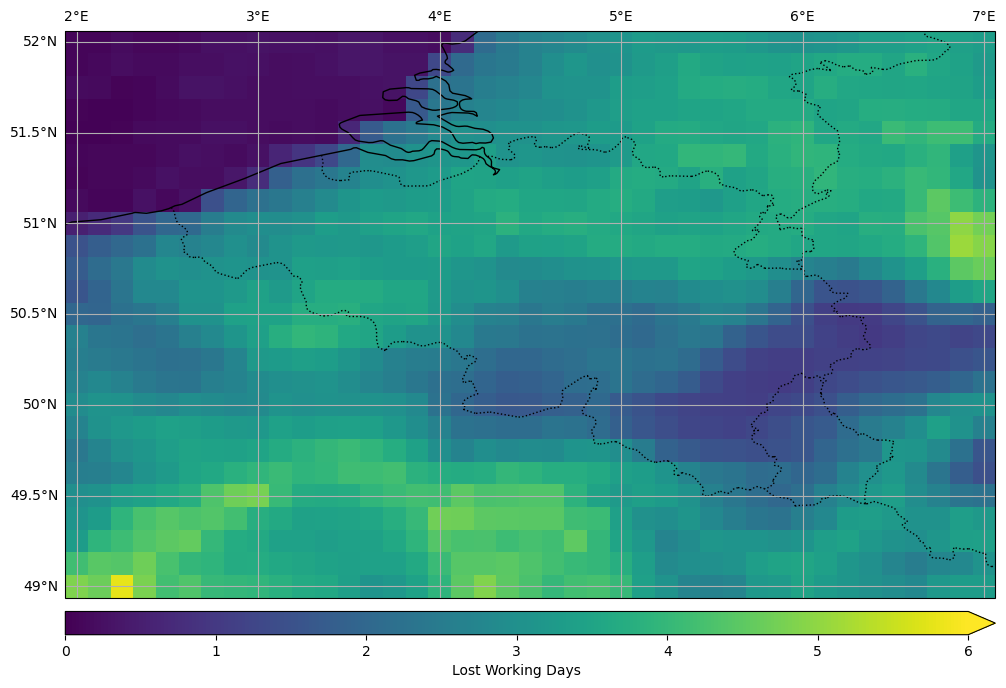

In [43]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature


# Create a figure and add a map projection
fig = plt.figure(figsize=(12, 9))
ax = plt.axes(projection=ccrs.PlateCarree())

# Plot the WBGT data for timestep 1000 (in Celsius)
p = ax.pcolormesh(
    lwh.lon, lwh.lat, lwh.sum(axis=2) / 14,
    transform=ccrs.PlateCarree(),
    cmap='viridis',
    shading='auto',
    vmin=0,
    vmax=6
)

# Add coastlines, borders, and gridlines
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
gl = ax.gridlines(draw_labels=True)
gl.bottom_labels = False
gl.right_labels = False

# Add colorbar
#cbar = plt.colorbar(p, ax=ax, orientation='horizontal', pad=0.02, aspect=30)
cbar = plt.colorbar(
    p, ax=ax, orientation='horizontal',
    pad=0.02, aspect=40,
    extend='max', extendfrac=0.03, shrink=1
)
cbar.set_label("Lost Working Days")

plt.show()